# Weibull Distribution

The **Weibull distribution** is the workhorse of reliability engineering. Its shape parameter γ makes the hazard function increasing (wear-out), constant (random), or decreasing (infant mortality) — allowing one distribution family to model the entire product lifecycle (bathtub curve).

| Property | Value |
|---|---|
| **Parameters** | γ (shape, γ > 0), β (scale, β > 0), μ (location) |
| **Support** | [μ, +∞) |
| **PDF** | f(x) = (γ/β)((x−μ)/β)^(γ−1) exp(−((x−μ)/β)^γ) |
| **CDF** | F(x) = 1 − exp(−((x−μ)/β)^γ) |
| **Mean** | μ + β Γ(1 + 1/γ) |
| **Hazard** | h(x) = (γ/β)((x−μ)/β)^(γ−1) |
| **γ < 1** | Decreasing hazard — infant mortality |
| **γ = 1** | Constant hazard — reduces to Exponential |
| **γ > 1** | Increasing hazard — wear-out failures |
| **γ ≈ 3.5** | Approximates Normal (skewness ≈ 0) |
| **Estimation** | MLE or Weibull probability plot (ln-ln transform) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

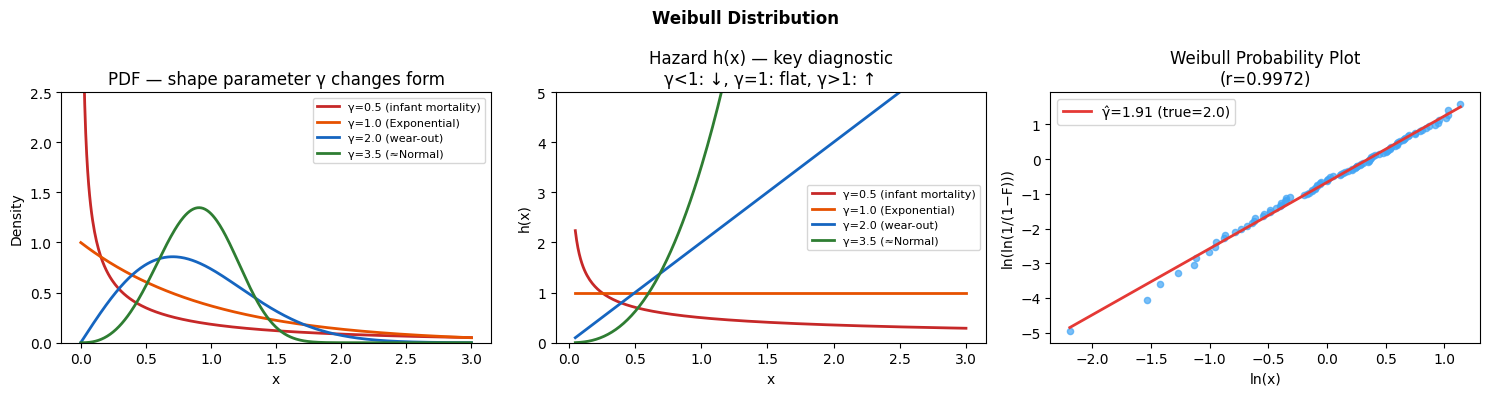

Weibull probability plot estimates: γ̂=1.908 (true=2.0), β̂=1.420 (true=1.5)


In [2]:
x = np.linspace(0.001, 3, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Weibull Distribution', fontsize=12, fontweight='bold')

# scipy uses 'c' for shape (= γ), scale for β
shapes = [(0.5, '#C62828', 'γ=0.5 (infant mortality)'),
          (1.0, '#E65100', 'γ=1.0 (Exponential)'),
          (2.0, '#1565C0', 'γ=2.0 (wear-out)'),
          (3.5, '#2E7D32', 'γ=3.5 (≈Normal)')]

# PDF
for gamma, color, label in shapes:
    axes[0].plot(x, stats.weibull_min(c=gamma, scale=1).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — shape parameter γ changes form')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 2.5)
axes[0].legend(fontsize=8)

# Hazard function
x_h = np.linspace(0.05, 3, 300)
for gamma, color, label in shapes:
    d = stats.weibull_min(c=gamma, scale=1)
    h = d.pdf(x_h) / d.sf(x_h)
    axes[1].plot(x_h, h, color=color, linewidth=2, label=label)
axes[1].set_title('Hazard h(x) — key diagnostic\nγ<1: ↓, γ=1: flat, γ>1: ↑')
axes[1].set_xlabel('x'); axes[1].set_ylabel('h(x)')
axes[1].set_ylim(0, 5)
axes[1].legend(fontsize=8)

# Weibull probability plot
np.random.seed(42)
true_gamma, true_beta = 2.0, 1.5
data = stats.weibull_min(c=true_gamma, scale=true_beta).rvs(100)
t_sorted = np.sort(data)
n = len(t_sorted)
i = np.arange(1, n+1)
F = (i - 0.3) / (n + 0.4)   # Benard's median rank
y = np.log(np.log(1/(1-F)))
x_plot = np.log(t_sorted)
slope, intercept, r, *_ = stats.linregress(x_plot, y)
axes[2].scatter(x_plot, y, color='#42A5F5', s=20, alpha=0.7)
axes[2].plot(x_plot, slope*x_plot + intercept, color='#E53935', linewidth=2,
             label=f'γ̂={slope:.2f} (true={true_gamma})')
axes[2].set_title(f'Weibull Probability Plot\n(r={r:.4f})')
axes[2].set_xlabel('ln(x)'); axes[2].set_ylabel('ln(ln(1/(1−F)))')
axes[2].legend()

plt.tight_layout()
plt.show()

eta_hat = np.exp(-intercept / slope)
print(f"Weibull probability plot estimates: γ̂={slope:.3f} (true={true_gamma}), β̂={eta_hat:.3f} (true={true_beta})")

## Key Takeaways

| | |
|---|---|
| **γ < 1** | Infant mortality — early failures dominate; hazard falls over time |
| **γ = 1** | Exponential — random failures; constant hazard |
| **γ > 1** | Wear-out — failures increase with age; hazard rises |
| **γ ≈ 3.5** | Nearly symmetric — approximates Normal |
| **Bathtub curve** | Full product lifecycle: infant (γ<1) → random (γ=1) → wear-out (γ>1) |
| **Probability plot** | ln(ln(1/(1−F))) vs ln(t): slope = γ, intercept gives β |
| **Scale β** | Characteristic life — 63.2% of units fail by time β (regardless of γ) |